# TCGA Pan-Cancer miRNA-to-Gene Feature Construction

## Overview

This pipeline implements a comprehensive preprocessing and transformation workflow for TCGA pan-cancer miRNA expression data. The goal is to convert raw miRNA profiles into biologically meaningful **gene-level features** by integrating experimentally validated miRNA–target interactions, enabling seamless incorporation into multi-omics learning frameworks.

The pipeline combines miRNA expression data, clinical phenotype annotations, and miRNA–gene regulatory networks to produce a structured representation suitable for downstream analysis such as cancer subtype characterization, graph neural network (GNN) modeling, and multi-omics integration.

---

## Key Objectives

- Standardize and clean TCGA miRNA expression data  
- Harmonize sample identifiers across datasets  
- Remove duplicate samples and invalid values  
- Normalize miRNA identifiers for consistent mapping  
- Integrate miRNA expression with miRTarBase interaction data  
- Construct gene-level features from miRNA regulatory signals  
- Align samples with cancer type annotations  
- Enable downstream visualization (PCA, UMAP, t-SNE) and modeling  

---

## Pipeline Description

### 1. Data Loading and Configuration

The pipeline initializes paths, configuration parameters, and reference mappings, including:

- TCGA phenotype annotations  
- miRTarBase interaction datasets with confidence-based weights  
- Cancer type mapping (TCGA 33 cancer types)  
- Visualization color schemes for reproducibility  

---

### 2. miRNA Expression Preprocessing

Raw miRNA expression data are:

- Loaded from TCGA (UCSC Xena)  
- Standardized using TCGA barcode truncation (first 15 characters)  
- Cleaned to remove invalid values (NaN and Inf)  
- Deduplicated by averaging repeated samples  

miRNA identifiers are normalized to ensure consistent mapping:

$$
\text{miRNA}_{normalized} = \text{lowercase}(\text{remove prefixes/suffixes})
$$

---

### 3. miRNA-to-Gene Mapping

We transform miRNA expression into gene-level features using weighted aggregation based on validated regulatory interactions:

$$
G_j = \sum_{i \in \mathcal{M}(j)} w_i \cdot x_i
$$

where:
- $G_j$ = inferred activity of gene $j$  
- $\mathcal{M}(j)$ = set of miRNAs targeting gene $j$  
- $x_i$ = expression of miRNA $i$  
- $w_i$ = interaction weight derived from experimental evidence  

Different evidence levels (e.g., strong vs weak validation) are incorporated via configurable weights.

---

### 4. Gene-Level Feature Refinement

The resulting gene matrix is further processed by:

- Removing invalid or malformed gene identifiers  
- Filtering low-information genes (all-zero rows)  
- Ensuring numerical stability and consistency  

---

### 5. Phenotype Integration

Clinical phenotype data are used to:

- Assign samples to TCGA cancer types  
- Filter invalid or unmapped samples  
- Enable cancer-specific aggregation and visualization  

---

### 6. Dimensionality Reduction and Visualization

To assess data structure and biological signal, we apply:

- **PCA**: captures global variance  
- **UMAP**: preserves manifold structure  
- **t-SNE**: emphasizes local clustering  

Each sample is embedded into a low-dimensional space:

$$
X \in \mathbb{R}^{n \times d} \rightarrow Z \in \mathbb{R}^{n \times 2}
$$

and visualized with consistent cancer-type color encoding.

---

## Outputs

The pipeline produces:

- Gene-level feature matrix derived from miRNA data  
- Cleaned and validated multi-omics-ready dataset  
- Low-dimensional embeddings for visualization  
- Cancer-type–annotated sample representations  

---

## Scientific Rationale

miRNAs regulate gene expression post-transcriptionally and play a critical role in cancer biology. By projecting miRNA expression into gene space using validated regulatory interactions, this pipeline captures **functional regulatory signals** rather than raw expression values alone.

This transformation improves interpretability and facilitates integration with other gene-centric omics data such as mutation and mRNA expression.

---

## Applications

The processed outputs can be used for:

- Multi-omics data integration  
- Graph neural network (GNN) modeling  
- Cancer subtype classification  
- Biomarker discovery  
- Network-based systems biology analysis  

---

## Reproducibility

The pipeline is fully modular and configurable, allowing adaptation to:

- Alternative miRNA–target databases  
- Different weighting strategies  
- Sample-level or cancer-level analysis  
- Additional omics layers  

All steps include validation checks to ensure numerical stability and data integrity.

## Imports

In [44]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import os
from gprofiler import GProfiler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


## Configuration

In [45]:
SAVE_DIR = "data/tcga"
os.makedirs(SAVE_DIR, exist_ok=True)

PHENO_FILE = "../data/phenotype/TCGA_phenotype_denseDataOnlyDownload.tsv.gz"

MIRTARBASE_FILES = {
    "SE_WR": ("../data/miRTarBase_SE_WR.csv", 3.0),  
    "SE_W":  ("../data/miRTarBase_SE_W.csv", 2.0),
    "SE_R":  ("../data/miRTarBase_SE_R.csv", 2.0),
    "WE_CLIP": ("../data/miRTarBase_WE_Clip.csv", 1.0),
    "WE_OTHER": ("../data/miRTarBase_WE_Other.csv", 1.0),
}


TCGA_33_MAP = {
    "adrenocortical carcinoma": "ACC",
    "bladder urothelial carcinoma": "BLCA",
    "breast invasive carcinoma": "BRCA",
    "cervical squamous cell carcinoma and endocervical adenocarcinoma": "CESC",
    "cholangiocarcinoma": "CHOL",
    "colon adenocarcinoma": "COAD",
    "lymphoid neoplasm diffuse large b-cell lymphoma": "DLBC",
    "esophageal carcinoma": "ESCA",
    "glioblastoma multiforme": "GBM",
    "head and neck squamous cell carcinoma": "HNSC",
    "kidney chromophobe": "KICH",
    "kidney renal clear cell carcinoma": "KIRC",
    "kidney renal papillary cell carcinoma": "KIRP",
    "acute myeloid leukemia": "LAML",
    "brain lower grade glioma": "LGG",
    "liver hepatocellular carcinoma": "LIHC",
    "lung adenocarcinoma": "LUAD",
    "lung squamous cell carcinoma": "LUSC",
    "mesothelioma": "MESO",
    "ovarian serous cystadenocarcinoma": "OV",
    "pancreatic adenocarcinoma": "PAAD",
    "pheochromocytoma and paraganglioma": "PCPG",
    "prostate adenocarcinoma": "PRAD",
    "rectum adenocarcinoma": "READ",
    "sarcoma": "SARC",
    "skin cutaneous melanoma": "SKCM",
    "stomach adenocarcinoma": "STAD",
    "testicular germ cell tumors": "TGCT",
    "thyroid carcinoma": "THCA",
    "thymoma": "THYM",
    "uterine corpus endometrial carcinoma": "UCEC",
    "uterine carcinosarcoma": "UCS",
    "uveal melanoma": "UVM"
}

COLORS = {
    0: '#0077B6',   1: '#0000FF',   2: '#00B4D8',   3: '#48EAC4',
    4: '#F1C0E8',   5: '#B9FBC0',   6: '#32CD32',   7: '#BEE1E6',
    8: '#8A2BE2',   9: '#E377C2',  10: '#8EECF5',  11: '#A3C4F3',
    12: '#FFB347', 13: '#FFD700',  14: '#FF69B4',  15: '#CD5C5C',
    16: '#7FFFD4', 17: '#FF7F50',  18: '#C71585',  19: '#20B2AA',
    20: '#6A5ACD', 21: '#40E0D0',  22: '#FF8C00',  23: '#DC143C',
    24: '#9ACD32',
    25: '#1F77B4', 26: '#FF1493', 27: '#2E8B57', 28: '#D2691E',
    29: '#9932CC', 30: '#00CED1', 31: '#FF4500', 32: '#708090'
}

## 1. Data Loading and Configuration

The pipeline initializes paths, configuration parameters, and reference mappings, including:

- TCGA phenotype annotations  
- miRTarBase interaction datasets with confidence-based weights  
- Cancer type mapping (TCGA 33 cancer types)  
- Visualization color schemes for reproducibility  

In [ ]:
mirna = pd.read_csv(
    "../data/_xena/pancanMiRs_EBadjOnProtocolPlatformWithoutRepsWithUnCorrectMiRs_08_04_16.xena",
    sep="\t"
)

mirna.rename(columns={mirna.columns[0]: "miRNA"}, inplace=True)
mirna.columns = ["miRNA"] + [c[:15] for c in mirna.columns[1:]]

FileNotFoundError: [Errno 2] No such file or directory: '../data/_pancanMiRs_EBadjOnProtocolPlatformWithoutRepsWithUnCorrectMiRs_08_04_16.xena'

## 2. miRNA Expression Preprocessing

Raw miRNA expression data are:

- Loaded from TCGA (UCSC Xena)  
- Standardized using TCGA barcode truncation (first 15 characters)  
- Cleaned to remove invalid values (NaN and Inf)  
- Deduplicated by averaging repeated samples  

miRNA identifiers are normalized to ensure consistent mapping:

$$
\text{miRNA}_{normalized} = \text{lowercase}(\text{remove prefixes/suffixes})
$$

We average duplicate TCGA barcodes.

In [47]:
# mirna_numeric = mirna.drop(columns=["miRNA"])
# mirna_numeric = mirna_numeric.groupby(mirna_numeric.columns, axis=1).mean()

# mirna = pd.concat([mirna["miRNA"], mirna_numeric], axis=1)

mirna_numeric = mirna.drop(columns=["miRNA"])

mirna_numeric = (
    mirna_numeric.T
    .groupby(level=0)
    .mean()
    .T
)

mirna = pd.concat([mirna["miRNA"], mirna_numeric], axis=1)

In [48]:
def validate_df(df, name="DataFrame"):
    print(f"\n[VALIDATE] {name}")
    print("Shape:", df.shape)

    # Check NaN / Inf
    n_nan = df.isna().sum().sum()
    n_inf = np.isinf(df.values).sum()

    print("NaN count:", n_nan)
    print("Inf count:", n_inf)

    if n_nan > 0 or n_inf > 0:
        print("⚠️ Cleaning invalid values...")
        df = df.replace([np.inf, -np.inf], np.nan)
        df = df.fillna(0)

    print("Min:", df.min().min())
    print("Max:", df.max().max())

    return df

In [49]:
mirna_vals = mirna.set_index("miRNA")
mirna_vals = validate_df(mirna_vals, "miRNA raw (log-scale)")
mirna = mirna_vals.reset_index()


[VALIDATE] miRNA raw (log-scale)
Shape: (743, 10818)
NaN count: 0
Inf count: 0
Min: -2.28
Max: 23.01


## 3. miRNA-to-Gene Mapping

We transform miRNA expression into gene-level features using weighted aggregation based on validated regulatory interactions:

$$
G_j = \sum_{i \in \mathcal{M}(j)} w_i \cdot x_i
$$

where:
- $G_j$ = inferred activity of gene $j$  
- $\mathcal{M}(j)$ = set of miRNAs targeting gene $j$  
- $x_i$ = expression of miRNA $i$  
- $w_i$ = interaction weight derived from experimental evidence  

Different evidence levels (e.g., strong vs weak validation) are incorporated via configurable weights.

In [50]:
def map_mirna_to_genes(mirna_df, mapping):
    genes = sorted({g for targets in mapping.values() for g, _ in targets})

    gene_matrix = pd.DataFrame(0.0, index=genes, columns=mirna_df.columns)

    for mir in tqdm(mirna_df.index, desc="Mapping miRNA → gene"):
        if mir not in mapping:
            continue

        vals = mirna_df.loc[mir].values

        if not np.isfinite(vals).all():
            continue  # skip bad rows

        for gene, weight in mapping[mir]:
            gene_matrix.loc[gene] += vals * weight

    gene_matrix = validate_df(gene_matrix, "Gene matrix (after mapping)")

    return gene_matrix.reset_index().rename(columns={"index": "gene"})

## 4. Cancer-Level Aggregation Function

The following function computes cancer-level feature representations by averaging sample-level data for each cancer type:

### Key Steps

- **Input structure**:
  - Rows represent **genes**
  - Columns represent **samples**

- **Sample alignment**:
  - Only samples present in both the feature matrix and phenotype data are retained

- **Grouping by cancer type**:
  - Samples are grouped based on their assigned cancer label

- **Aggregation**:
  - For each cancer type \(k\), the mean feature vector is computed:
    \[
    \mathbf{c}_k = \frac{1}{|\mathcal{S}_k|} \sum_{i \in \mathcal{S}_k} \mathbf{x}_i
    \]

- **Handling invalid values**:
  - Non-finite values (NaN, ±∞) are replaced with zero before aggregation

- **Output structure**:
  - A **gene × cancer matrix**, where:
    - rows = genes  
    - columns = cancer types  

### Purpose

This step converts high-dimensional sample-level data into a compact representation of each cancer type, enabling downstream analysis such as clustering, visualization, and machine learning.

In [51]:
def aggregate(df, pheno_df):
    df = df.set_index("gene")

    common = list(set(df.columns) & set(pheno_df["Sample"]))
    df = df[common]

    pheno_df = pheno_df[pheno_df["Sample"].isin(common)]

    result = {}

    for cancer in pheno_df["Cancer"].unique():
        samples = pheno_df[pheno_df["Cancer"] == cancer]["Sample"]

        mat = df[samples].values

        # safe mean
        mat = np.where(np.isfinite(mat), mat, 0)

        result[cancer] = mat.mean(axis=1)

    result_df = pd.DataFrame(result, index=df.index)

    result_df = validate_df(result_df, "Cancer aggregated matrix")

    result_df.insert(0, "gene", result_df.index)
    return result_df.reset_index(drop=True)

## Normalize miRNA Names

In [52]:
def normalize_mir(m):
    return str(m).lower().replace("hsa-", "").replace("*", "").strip()

mirna["miRNA"] = mirna["miRNA"].map(normalize_mir)
mirna.set_index("miRNA", inplace=True)

## Load Phenotype (Cancer Labels)

In [53]:
pheno = pd.read_csv(PHENO_FILE, sep="\t", compression="gzip")
pheno["Sample"] = pheno["sample"]

# Extract TCGA cancer code directly
pheno["Cancer"] = pheno["sample"].str[13:15]
pheno = pheno.dropna(subset=["Cancer"])

## 5. Gene-Level Feature Refinement

The resulting gene matrix is further processed by:

- Removing invalid or malformed gene identifiers  
- Filtering low-information genes (all-zero rows)  
- Ensuring numerical stability and consistency

In [54]:
pheno = pd.read_csv(PHENO_FILE, sep="\t", compression="gzip")

# clean
pheno["_primary_disease"] = (
    pheno["_primary_disease"]
    .str.strip()
    .str.lower()
)

# map to TCGA codes
pheno["Cancer"] = pheno["_primary_disease"].map(TCGA_33_MAP)

# keep only mapped cancers
pheno = pheno.dropna(subset=["Cancer"])

# sample column
pheno["Sample"] = pheno["sample"]

## Load miRTarBase Mapping

Weighted mapping:

$$Gene = \sum (w_i \cdot miRNA_i)$$

In [55]:
def load_mirtarbase(files):
    mapping = {}
    for key, (path, weight) in files.items():
        df = pd.read_csv(path)

        mir_col = next(c for c in df.columns if "miRNA" in c)
        gene_col = next(c for c in df.columns if "Target Gene" in c)

        for mir, gene in zip(df[mir_col], df[gene_col]):
            mir = normalize_mir(mir)
            gene = str(gene).upper().strip()
            mapping.setdefault(mir, []).append((gene, weight))
    return mapping

mirna_targets = load_mirtarbase(MIRTARBASE_FILES)

## Map miRNA → Gene Matrix

In [56]:

def map_mirna_to_genes(mirna_df, mapping):
    genes = sorted({g for targets in mapping.values() for g, _ in targets})

    gene_matrix = pd.DataFrame(0.0, index=genes, columns=mirna_df.columns)

    for mir in tqdm(mirna_df.index, desc="Mapping miRNA → gene"):
        if mir not in mapping:
            continue

        vals = mirna_df.loc[mir].values

        if not np.isfinite(vals).all():
            continue  # skip bad rows

        for gene, weight in mapping[mir]:
            gene_matrix.loc[gene] += vals * weight

    gene_matrix = validate_df(gene_matrix, "Gene matrix (after mapping)")

    return gene_matrix.reset_index().rename(columns={"index": "gene"})

## Run Mapping

In [57]:
mirna_gene_matrix = map_mirna_to_genes(mirna, mirna_targets)

Mapping miRNA → gene: 100%|██████████| 743/743 [03:36<00:00,  3.43it/s]



[VALIDATE] Gene matrix (after mapping)
Shape: (19342, 10818)
NaN count: 0
Inf count: 0
Min: -78.98999999999977
Max: 38143.37000000035


## Clean Gene Names

In [58]:
mirna_gene_matrix["gene"] = mirna_gene_matrix["gene"].str.upper()
mirna_gene_matrix = mirna_gene_matrix.dropna()
mirna_gene_matrix

,gene,TCGA-04-1331-01,TCGA-04-1336-01,TCGA-04-1337-01,TCGA-04-1341-01,TCGA-04-1342-01,TCGA-04-1343-01,TCGA-04-1346-01,TCGA-04-1347-01,TCGA-04-1348-01,...,TCGA-ZR-A9CJ-01,TCGA-ZS-A9CD-01,TCGA-ZS-A9CE-01,TCGA-ZS-A9CF-01,TCGA-ZS-A9CF-02,TCGA-ZS-A9CG-01,TCGA-ZT-A8OM-01,TCGA-ZU-A8S4-01,TCGA-ZU-A8S4-11,TCGA-ZX-AA5X-01
0,0610009B22RIK,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0610010K14RIK,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0610030E20RIK,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,0610040J01RIK,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,1110004F10RIK,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19337,ZYG11A,305.51,249.35,345.12,318.19,306.01,340.90,313.87,277.40,313.71,...,248.91,291.17,274.64,286.45,261.90,295.51,539.85,257.29,290.10,259.95
19338,ZYG11B,560.60,472.67,609.52,584.54,575.74,642.71,632.93,515.42,548.98,...,568.19,607.73,639.75,621.22,625.73,549.84,990.31,554.15,597.69,583.16
19339,ZYX,282.89,264.88,239.26,292.35,302.77,300.63,282.48,284.37,325.64,...,318.63,324.82,323.23,353.89,345.75,325.52,440.92,313.97,316.22,329.17
19340,ZZEF1,125.99,117.88,117.99,131.98,122.56,136.57,134.24,120.69,124.13,...,82.95,82.01,83.72,74.48,81.48,74.95,117.33,85.70,74.03,81.73


In [59]:
# remove invalid genes
mirna_gene_matrix = mirna_gene_matrix[
    mirna_gene_matrix["gene"].str.match(r"^[A-Z0-9\-]{2,}$")
]

mirna_gene_matrix = mirna_gene_matrix[
    ~mirna_gene_matrix["gene"].str.endswith("RIK")
]

# remove all-zero genes
mirna_gene_matrix = mirna_gene_matrix[
    ~(mirna_gene_matrix.iloc[:, 1:] == 0).all(axis=1)
]

mirna_gene_matrix

,gene,TCGA-04-1331-01,TCGA-04-1336-01,TCGA-04-1337-01,TCGA-04-1341-01,TCGA-04-1342-01,TCGA-04-1343-01,TCGA-04-1346-01,TCGA-04-1347-01,TCGA-04-1348-01,...,TCGA-ZR-A9CJ-01,TCGA-ZS-A9CD-01,TCGA-ZS-A9CE-01,TCGA-ZS-A9CF-01,TCGA-ZS-A9CF-02,TCGA-ZS-A9CG-01,TCGA-ZT-A8OM-01,TCGA-ZU-A8S4-01,TCGA-ZU-A8S4-11,TCGA-ZX-AA5X-01
208,A1BG,40.04,29.24,42.28,47.44,41.72,45.30,46.64,35.52,53.04,...,56.02,42.92,41.88,43.32,42.20,34.04,78.52,60.72,56.64,62.84
209,A1CF,254.57,227.06,251.07,245.07,240.49,257.16,242.63,264.95,227.64,...,227.23,226.06,229.43,239.12,231.77,239.43,415.63,211.19,236.24,224.09
210,A2M,64.88,62.20,55.89,74.58,72.06,68.14,75.76,61.35,72.52,...,79.53,102.89,99.71,84.78,81.41,112.12,97.12,94.24,101.86,88.88
211,A2ML1,298.69,181.36,355.25,372.87,321.07,379.44,346.15,273.36,317.84,...,324.50,359.70,259.50,264.23,255.36,211.32,376.71,336.04,332.06,400.88
216,A4GALT,81.77,101.56,98.44,107.92,97.99,115.72,99.63,95.09,93.63,...,52.38,54.38,56.96,60.67,47.89,57.04,65.91,56.53,60.18,45.59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19337,ZYG11A,305.51,249.35,345.12,318.19,306.01,340.90,313.87,277.40,313.71,...,248.91,291.17,274.64,286.45,261.90,295.51,539.85,257.29,290.10,259.95
19338,ZYG11B,560.60,472.67,609.52,584.54,575.74,642.71,632.93,515.42,548.98,...,568.19,607.73,639.75,621.22,625.73,549.84,990.31,554.15,597.69,583.16
19339,ZYX,282.89,264.88,239.26,292.35,302.77,300.63,282.48,284.37,325.64,...,318.63,324.82,323.23,353.89,345.75,325.52,440.92,313.97,316.22,329.17
19340,ZZEF1,125.99,117.88,117.99,131.98,122.56,136.57,134.24,120.69,124.13,...,82.95,82.01,83.72,74.48,81.48,74.95,117.33,85.70,74.03,81.73



[VALIDATE] input (miRNA sample-level)
Shape: (10818, 743)
NaN count: 0
Inf count: 0
Min: -2.28
Max: 23.01


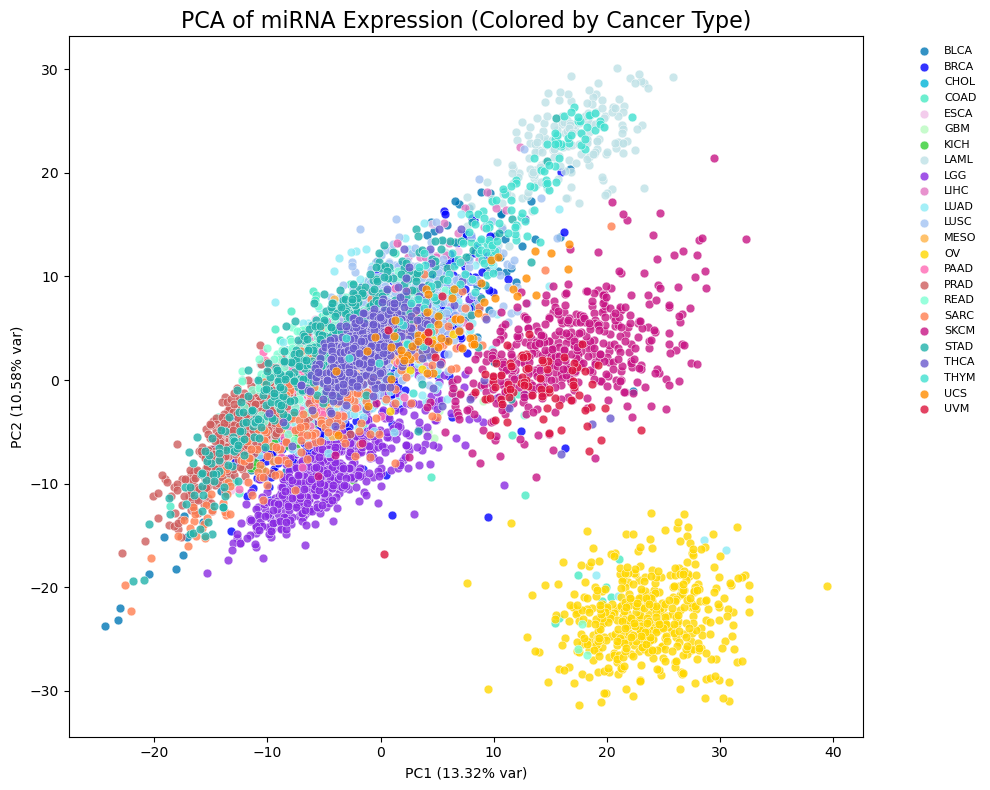

In [60]:
# -------------------------------
# Prepare data (samples × features)
# -------------------------------
mirna_sample = mirna.copy()

if "miRNA" in mirna_sample.columns:
    mirna_sample = mirna_sample.set_index("miRNA")

X = mirna_sample.T  # samples × features

# clean
X = validate_df(X, "input (miRNA sample-level)")

# -------------------------------
# Align with phenotype (SAFE)
# -------------------------------
common_samples = X.index.intersection(pheno["Sample"])

X = X.loc[common_samples]
labels = pheno.set_index("Sample").loc[common_samples, "Cancer"]



# -------------------------------
# Standardization
# -------------------------------
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# PCA
# -------------------------------
from sklearn.decomposition import PCA

pca_model = PCA(n_components=2, random_state=42)
pca_embedding = pca_model.fit_transform(X_scaled)

var_exp = pca_model.explained_variance_ratio_

# -------------------------------
# Build label IDs + mapping
# -------------------------------
unique_cancers = sorted(labels.unique())

cancer_to_id = {c: i for i, c in enumerate(unique_cancers)}
label_ids = labels.map(cancer_to_id).values

# -------------------------------
# Plot
# -------------------------------
plt.figure(figsize=(10, 8))

for cancer, cid in cancer_to_id.items():
    idx = label_ids == cid
    
    plt.scatter(
        pca_embedding[idx, 0],
        pca_embedding[idx, 1],

        s=40,                         # bigger points
        alpha=0.8,

        color=COLORS.get(cid, "#333333"),

        edgecolors="white",          # 🔥 outline
        linewidths=0.4,

        label=cancer
    )

# -------------------------------
# Labels
# -------------------------------
plt.xlabel(f"PC1 ({var_exp[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({var_exp[1]*100:.2f}% var)")
plt.title("PCA of miRNA Expression (Colored by Cancer Type)", fontsize=16)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8,
    frameon=False
)

plt.tight_layout()
plt.show()

## UMAP Visualization of miRNA Profiles

To explore the global structure of miRNA expression patterns across samples, we apply Uniform Manifold Approximation and Projection (UMAP), a nonlinear dimensionality reduction technique that preserves both local and global data structure.

Given a high-dimensional miRNA expression matrix:

$$
X \in \mathbb{R}^{n \times d}
$$

where:
- $n$ = number of samples  
- $d$ = number of miRNAs  

UMAP learns a low-dimensional embedding:

$$
Z = \mathrm{UMAP}(X), \quad Z \in \mathbb{R}^{n \times 2}
$$

such that the pairwise relationships between samples are preserved.


### Interpretation

Each point in the UMAP plot represents a tumor sample. Clustering patterns may indicate:

- Cancer type–specific miRNA signatures  
- Shared regulatory programs across cancers  
- Outlier samples or batch effects  

This visualization serves as a quality-control step before downstream multi-omics integration.

In [61]:
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# Prepare data (samples × features)
# -------------------------------
mirna_sample = mirna.copy()

if "miRNA" in mirna_sample.columns:
    mirna_sample = mirna_sample.set_index("miRNA")

X = mirna_sample.T  # samples × features

# clean
X = validate_df(X, "UMAP input (miRNA sample-level)")

# -------------------------------
# Align with phenotype (SAFE)
# -------------------------------
common_samples = X.index.intersection(pheno["Sample"])

X = X.loc[common_samples]
labels = pheno.set_index("Sample").loc[common_samples, "Cancer"]

# # -------------------------------
# # Log transform (IMPORTANT for miRNA)
# # -------------------------------
# X = np.log1p(X)

# -------------------------------
# Standardization
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# UMAP
# -------------------------------
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42
)

embedding = umap_model.fit_transform(X_scaled)

# -------------------------------
# Build plotting DataFrame
# -------------------------------
plot_df = pd.DataFrame({
    "UMAP1": embedding[:, 0],
    "UMAP2": embedding[:, 1],
    "Cancer": labels.values
}, index=common_samples)



[VALIDATE] UMAP input (miRNA sample-level)
Shape: (10818, 743)
NaN count: 0
Inf count: 0
Min: -2.28
Max: 23.01


/home/eric_karma/anaconda3/envs/reactome_gnn/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## t-SNE Visualization of miRNA Profiles

We further apply t-distributed Stochastic Neighbor Embedding (t-SNE), a nonlinear dimensionality reduction method that emphasizes preservation of local structure in high-dimensional data.

Given a high-dimensional dataset:

$$
X \in \mathbb{R}^{n \times d}
$$

t-SNE converts pairwise distances into probabilities and minimizes the divergence between high-dimensional and low-dimensional distributions:

$$
\mathrm{KL}(P \parallel Q)
$$

where:
- $P$ represents similarities in high-dimensional space  
- $Q$ represents similarities in low-dimensional space  

---

### Properties of t-SNE

- Strongly preserves local neighborhoods  
- Effective for revealing clusters  
- Nonlinear and stochastic (results may vary slightly)  
- Sensitive to hyperparameters (e.g., perplexity)

---

### Interpretation

- Each point represents a tumor sample  
- Clusters indicate similar miRNA expression profiles  
- Often reveals finer subgroup structures than PCA  

t-SNE complements PCA and UMAP by providing a highly localized view of sample relationships.

Explained variance (first 50 PCs): 0.7655197083023756
Missing Type: 0
Cancer types: 24
Type    Additional Metastatic  Metastatic  \
Cancer                                      
BLCA                        0           1   
BRCA                        0           7   
CHOL                        0           0   
COAD                        0           1   
ESCA                        0           1   
GBM                         0           0   
KICH                        0           0   
LAML                        0           0   
LGG                         0           0   
LIHC                        0           0   
LUAD                        0           0   
LUSC                        0           0   
MESO                        0           0   
OV                          0           0   
PAAD                        0           1   
PRAD                        0           1   
READ                        0           0   
SARC                        0           1   
SKCM         

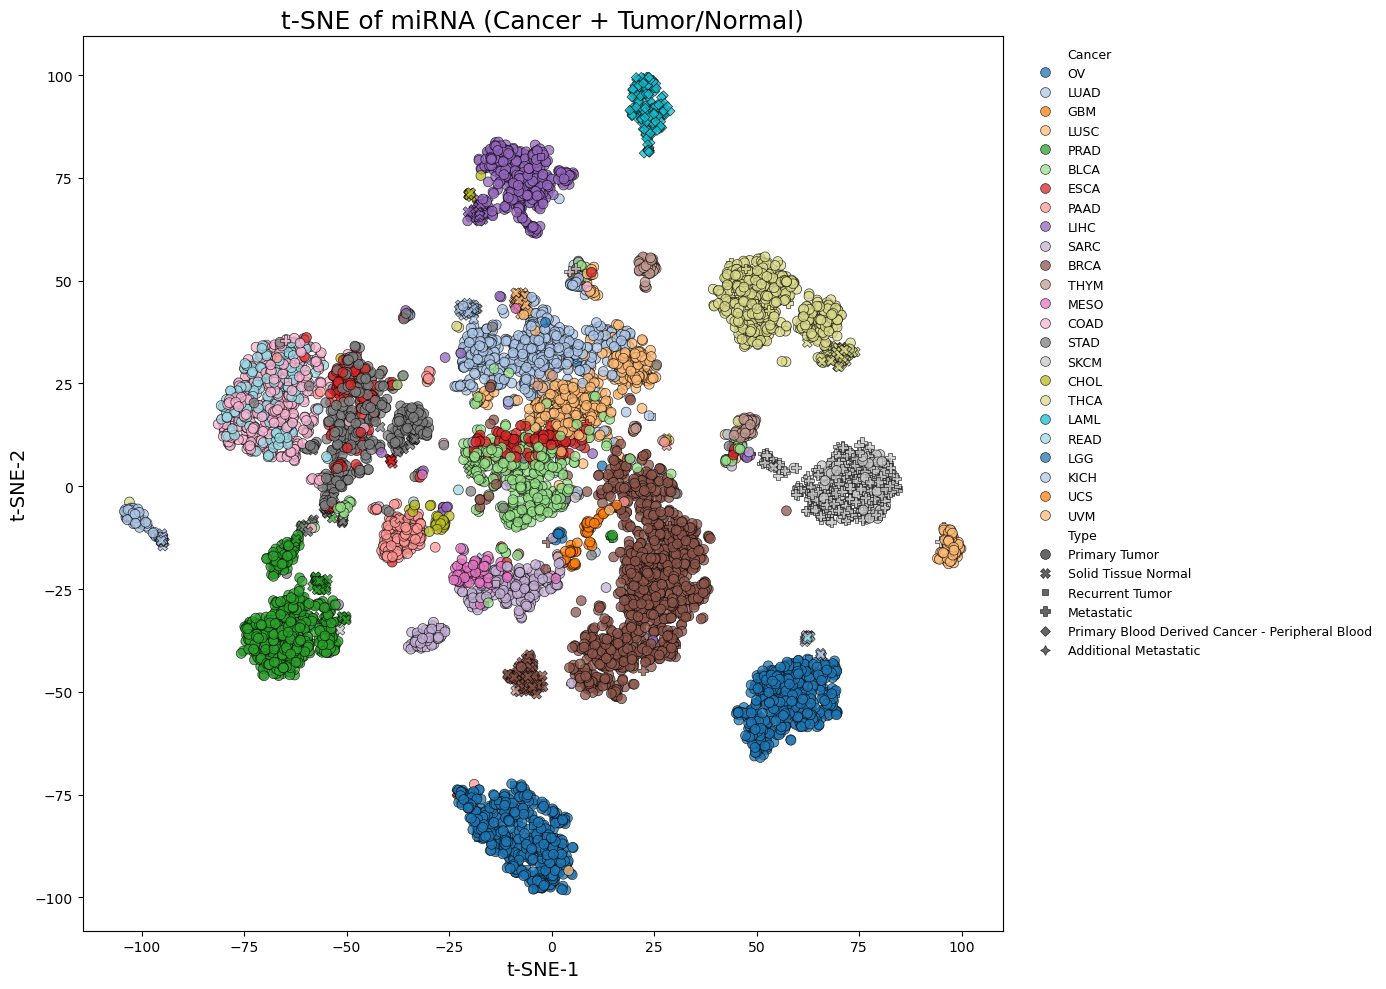

In [63]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# # -------------------------------
# # 1. SCALE + STABILIZE
# # -------------------------------
# # log transform (important for miRNA)
# X_log = np.log1p(X)

# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 2. PCA (VERY IMPORTANT before t-SNE)
# -------------------------------
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance (first 50 PCs):",
      np.sum(pca.explained_variance_ratio_))

# -------------------------------
# 3. t-SNE
# -------------------------------
tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1500,        # increased
    random_state=42,
    init="pca",
    early_exaggeration=12
)

tsne_embedding = tsne_model.fit_transform(X_pca)

# -------------------------------
# 4. BUILD DATAFRAME (SAFE ALIGNMENT)
# -------------------------------
plot_df = pd.DataFrame(
    tsne_embedding,
    columns=["TSNE1", "TSNE2"],
    index=common_samples
)

# add cancer labels
plot_df["Cancer"] = labels.loc[plot_df.index].values

# -------------------------------
# 5. ADD SAMPLE TYPE (FIXED)
# -------------------------------
pheno_indexed = pheno.set_index("Sample")

plot_df["Type"] = pheno_indexed.loc[plot_df.index, "sample_type"]

# -------------------------------
# 6. SANITY CHECKS (IMPORTANT)
# -------------------------------
print("Missing Type:", plot_df["Type"].isna().sum())
print("Cancer types:", plot_df["Cancer"].nunique())

# Crosstab = overlap diagnostic
print(pd.crosstab(plot_df["Cancer"], plot_df["Type"]))

# -------------------------------
# 7. OPTIONAL: JITTER (reduce overlap)
# -------------------------------
plot_df["TSNE1_j"] = plot_df["TSNE1"] + np.random.normal(0, 0.3, len(plot_df))
plot_df["TSNE2_j"] = plot_df["TSNE2"] + np.random.normal(0, 0.3, len(plot_df))

# -------------------------------
# 8. PLOT (IMPROVED)
# -------------------------------
plt.figure(figsize=(14, 10))

sns.scatterplot(
    data=plot_df,
    x="TSNE1_j",
    y="TSNE2_j",

    hue="Cancer",
    style="Type",

    palette=sns.color_palette("tab20", n_colors=plot_df["Cancer"].nunique()),

    s=50,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.5
)

plt.xlabel("t-SNE-1", fontsize=14)
plt.ylabel("t-SNE-2", fontsize=14)
plt.title("t-SNE of miRNA (Cancer + Tumor/Normal)", fontsize=18)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
    frameon=False
)

plt.tight_layout()
plt.show()

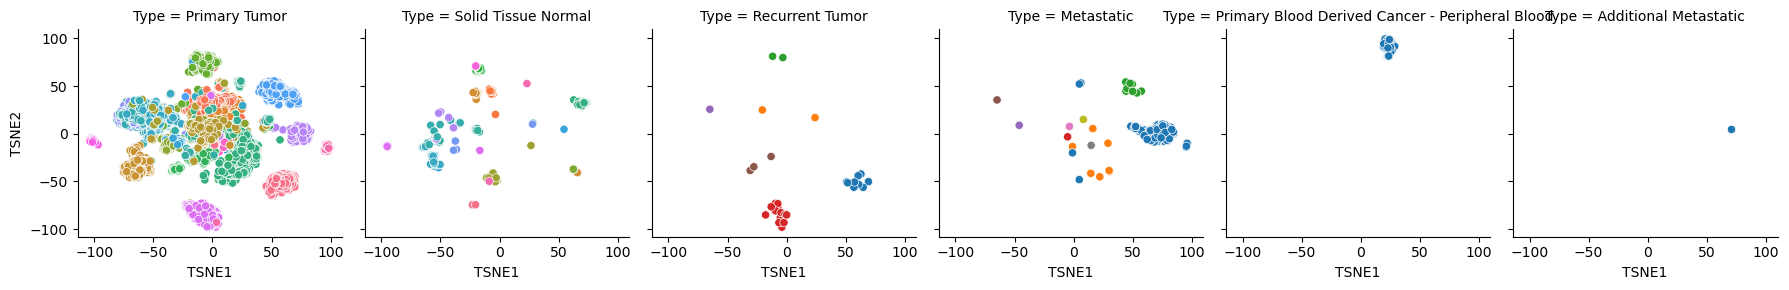

In [64]:
sns.FacetGrid(plot_df, col="Type").map_dataframe(
    sns.scatterplot, x="TSNE1", y="TSNE2", hue="Cancer"
)

Explained variance (first 50 PCs): 0.7655197083023756


/home/eric_karma/anaconda3/envs/reactome_gnn/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Missing Type: 0
Cancer types: 24
Type    Additional Metastatic  Metastatic  \
Cancer                                      
BLCA                        0           1   
BRCA                        0           7   
CHOL                        0           0   
COAD                        0           1   
ESCA                        0           1   
GBM                         0           0   
KICH                        0           0   
LAML                        0           0   
LGG                         0           0   
LIHC                        0           0   
LUAD                        0           0   
LUSC                        0           0   
MESO                        0           0   
OV                          0           0   
PAAD                        0           1   
PRAD                        0           1   
READ                        0           0   
SARC                        0           1   
SKCM                        1         352   
STAD                  

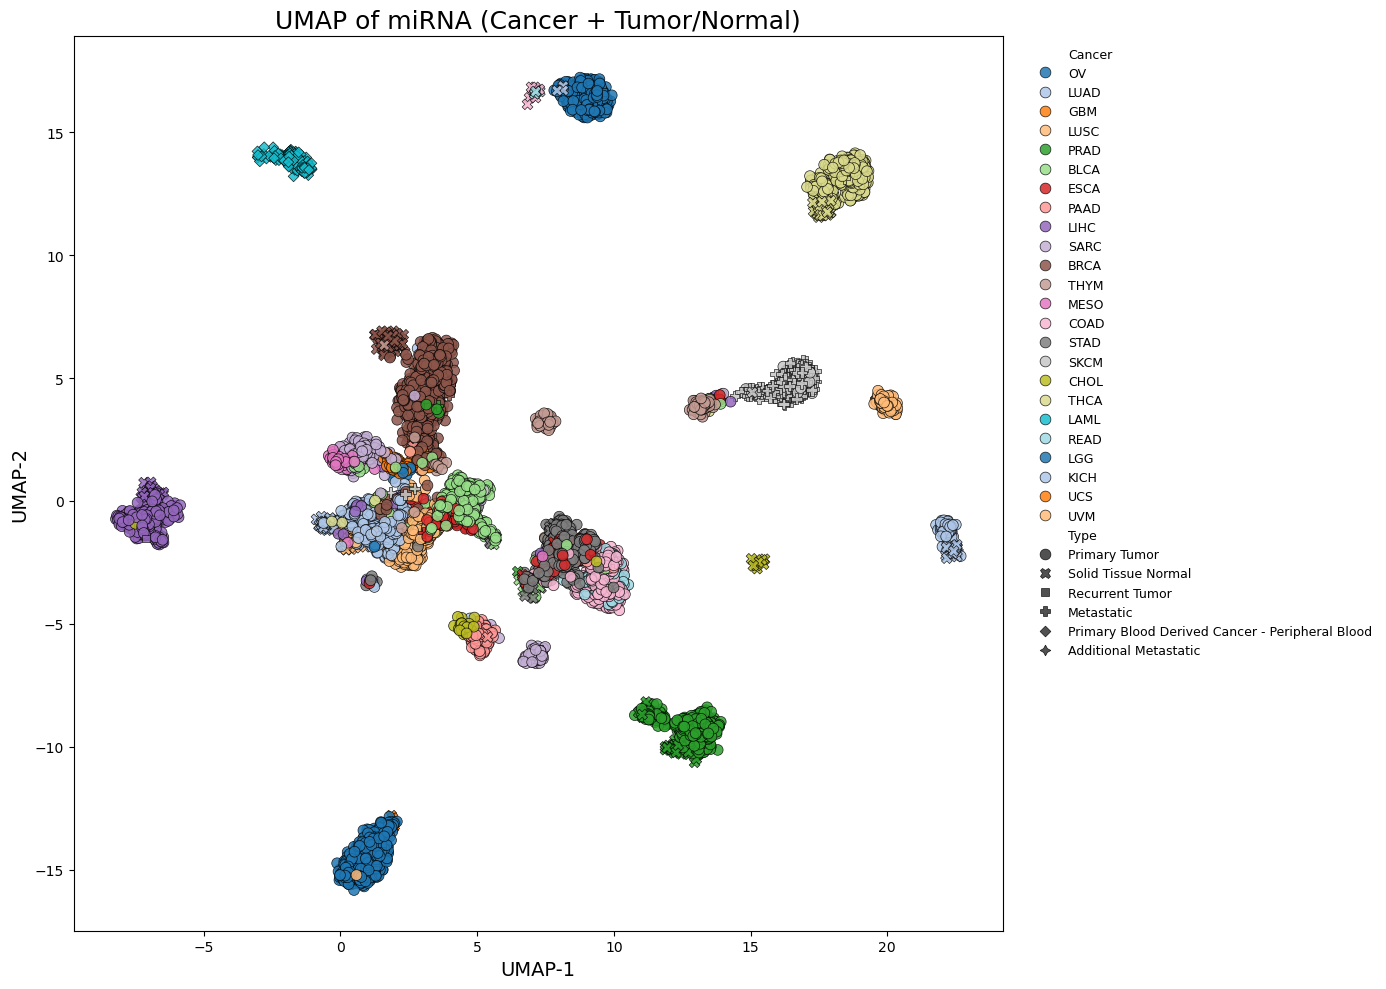

In [65]:
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 2. PCA (denoise before UMAP)
# -------------------------------
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance (first 50 PCs):",
      np.sum(pca.explained_variance_ratio_))

# -------------------------------
# 3. UMAP (REPLACES t-SNE)
# -------------------------------
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,     # local structure (smaller = tighter clusters)
    min_dist=0.1,       # cluster compactness
    metric="euclidean",
    random_state=42
)

umap_embedding = umap_model.fit_transform(X_pca)

# -------------------------------
# 4. BUILD DATAFRAME (SAFE ALIGNMENT)
# -------------------------------
plot_df = pd.DataFrame(
    umap_embedding,
    columns=["UMAP1", "UMAP2"],
    index=common_samples
)

# add cancer labels (SAFE)
plot_df["Cancer"] = labels.loc[plot_df.index]

# -------------------------------
# 5. ADD SAMPLE TYPE (FIXED)
# -------------------------------
pheno_indexed = pheno.set_index("Sample")

plot_df["Type"] = pheno_indexed.loc[plot_df.index, "sample_type"]

# -------------------------------
# 6. SANITY CHECKS
# -------------------------------
print("Missing Type:", plot_df["Type"].isna().sum())
print("Cancer types:", plot_df["Cancer"].nunique())
print(pd.crosstab(plot_df["Cancer"], plot_df["Type"]))

# -------------------------------
# 7. OPTIONAL: JITTER (less needed for UMAP)
# -------------------------------
plot_df["UMAP1_j"] = plot_df["UMAP1"] + np.random.normal(0, 0.15, len(plot_df))
plot_df["UMAP2_j"] = plot_df["UMAP2"] + np.random.normal(0, 0.15, len(plot_df))

# -------------------------------
# 8. PLOT (IMPROVED)
# -------------------------------
plt.figure(figsize=(14, 10))

sns.scatterplot(
    data=plot_df,
    x="UMAP1_j",
    y="UMAP2_j",

    hue="Cancer",
    style="Type",

    palette=sns.color_palette("tab20", n_colors=plot_df["Cancer"].nunique()),

    s=60,                # slightly bigger
    alpha=0.85,

    edgecolor="black",   # 🔥 THIS adds circle border
    linewidth=0.5        # thickness of border
)

plt.xlabel("UMAP-1", fontsize=14)
plt.ylabel("UMAP-2", fontsize=14)
plt.title("UMAP of miRNA (Cancer + Tumor/Normal)", fontsize=18)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
    frameon=False
)

plt.tight_layout()
plt.show()



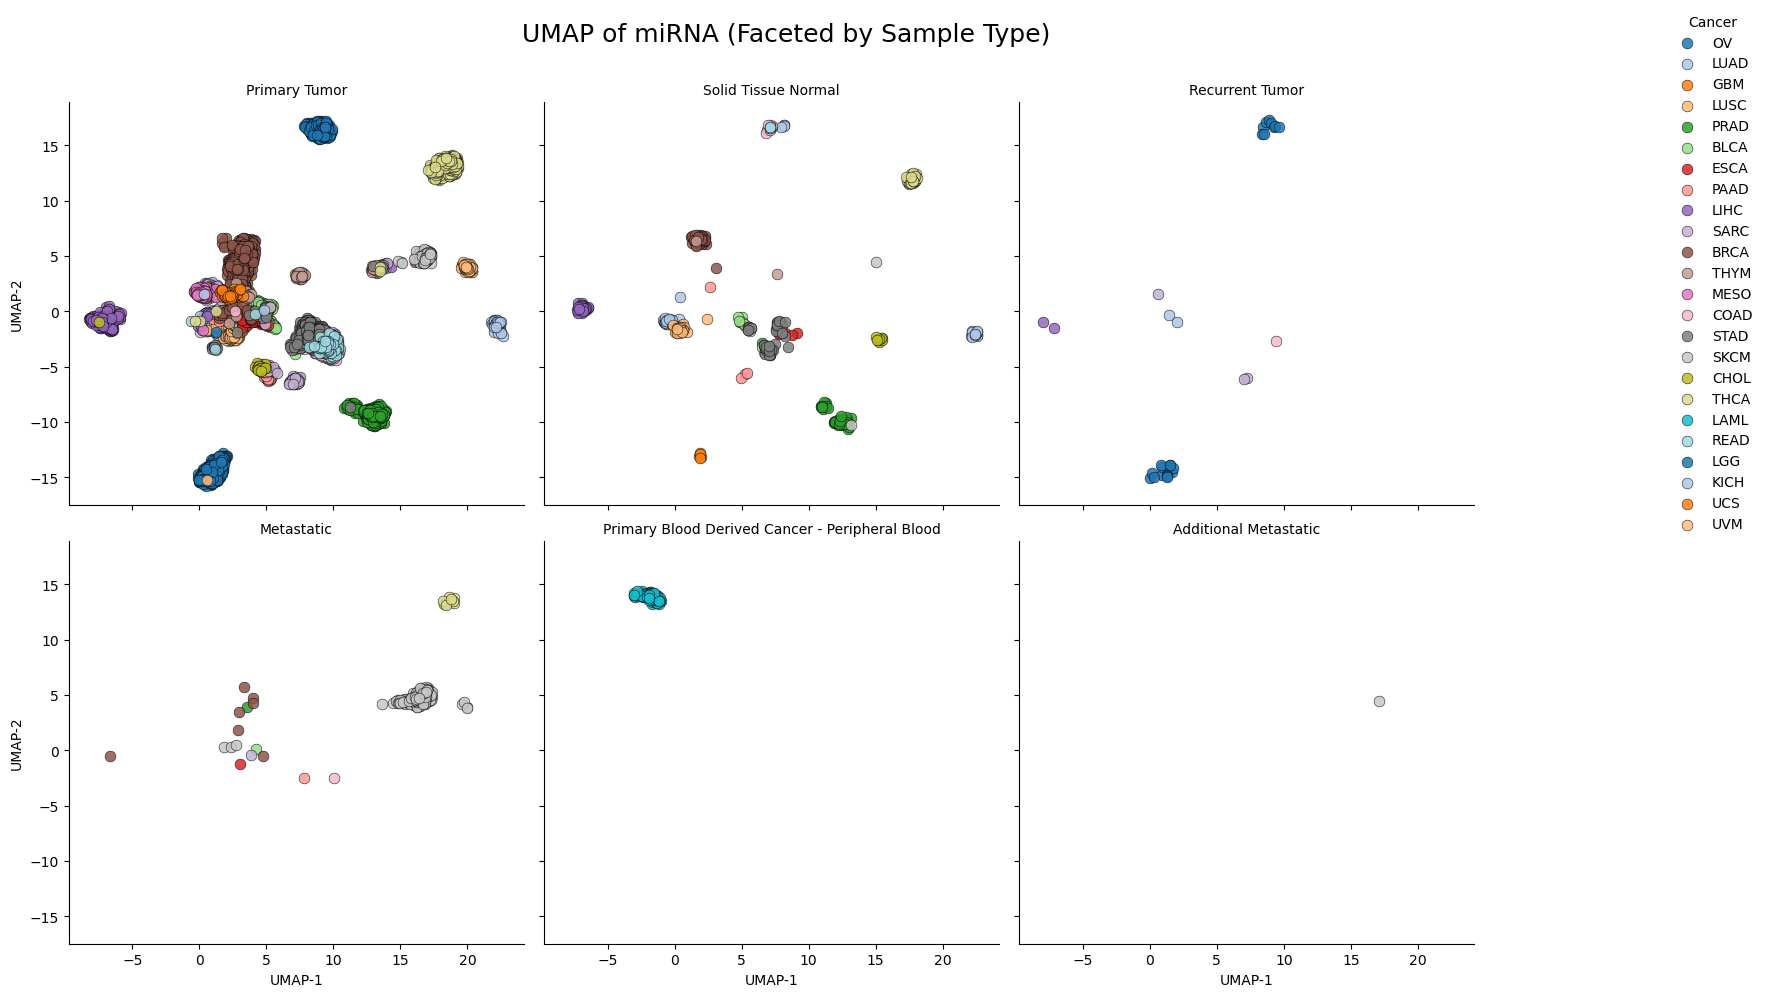

In [66]:
# -------------------------------
# Facet UMAP by sample Type
# -------------------------------
g = sns.FacetGrid(
    plot_df,
    col="Type",                  # split panels
    hue="Cancer",                # color by cancer
    col_wrap=3,                  # wrap layout (adjust if needed)
    height=5,

    palette=sns.color_palette(
        "tab20", 
        n_colors=plot_df["Cancer"].nunique()
    ),

    sharex=True,
    sharey=True
)

# scatter inside each facet
g.map_dataframe(
    sns.scatterplot,
    x="UMAP1_j",
    y="UMAP2_j",

    s=60,
    alpha=0.85,

    edgecolor="black",   # 🔥 circle border
    linewidth=0.4
)

# -------------------------------
# Formatting
# -------------------------------
g.set_axis_labels("UMAP-1", "UMAP-2")

g.set_titles(col_template="{col_name}")

# single legend (clean)
g.add_legend(
    title="Cancer",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.subplots_adjust(top=0.9)
g.fig.suptitle("UMAP of miRNA (Faceted by Sample Type)", fontsize=18)

plt.show()

Gene-Level miRNA Signal Across TCGA Cancers

We visualize the distribution of miRNA-derived gene activity across cancers, grouped by:

Cancer Gene Census (CGC)
Tumor Suppressor Genes (TSG)
Oncogenes
Other genes

This helps assess whether biologically relevant genes show distinct miRNA regulation patterns.

# Gene-Level miRNA Signal Across TCGA Cancers

We visualize the distribution of miRNA-derived gene activity across cancers, grouped by:

Cancer Gene Census (CGC)
Tumor Suppressor Genes (TSG)
Oncogenes
Other genes

This helps assess whether biologically relevant genes show distinct miRNA regulation patterns.

<!-- Consistent clustering patterns across PCA, UMAP, and t-SNE visualizations demonstrate that miRNA expression profiles capture robust cancer-type–specific structure. -->

## Aggregate by Cancer

We compute mean across samples:

$$X_{gene,cancer} = \frac{1}{N} \sum_{samples} X_{gene,sample}$$

In [67]:

def aggregate(df, pheno_df):
    df = df.set_index("gene")

    common = list(set(df.columns) & set(pheno_df["Sample"]))
    df = df[common]

    pheno_df = pheno_df[pheno_df["Sample"].isin(common)]

    result = {}

    for cancer in pheno_df["Cancer"].unique():
        samples = pheno_df[pheno_df["Cancer"] == cancer]["Sample"]

        mat = df[samples].values

        # safe mean
        mat = np.where(np.isfinite(mat), mat, 0)

        result[cancer] = mat.mean(axis=1)

    result_df = pd.DataFrame(result, index=df.index)

    result_df = validate_df(result_df, "Cancer aggregated matrix")

    result_df.insert(0, "gene", result_df.index)
    return result_df.reset_index(drop=True)

mirna_df = aggregate(mirna_gene_matrix, pheno)


[VALIDATE] Cancer aggregated matrix
Shape: (16422, 24)
NaN count: 0
Inf count: 0
Min: -9.88977011494253
Max: 35357.63785714288


In [68]:
mirna_df = validate_df(mirna_df.set_index("gene"), "FINAL miRNA matrix")
mirna_df = mirna_df.reset_index()

assert np.isfinite(mirna_df.iloc[:, 1:].values).all(), "❌ Still contains invalid values!"
print("✅ Final matrix is clean and safe")


[VALIDATE] FINAL miRNA matrix
Shape: (16422, 24)
NaN count: 0
Inf count: 0
Min: -9.88977011494253
Max: 35357.63785714288
✅ Final matrix is clean and safe


In [69]:
# %%
from sklearn.preprocessing import StandardScaler

mirna_values = mirna_df.iloc[:, 1:]  # exclude gene column

scaler = StandardScaler()
mirna_scaled = scaler.fit_transform(mirna_values)

mirna_df_norm = pd.DataFrame(
    mirna_scaled,
    columns=mirna_values.columns
)

mirna_df_norm.insert(0, "gene", mirna_df["gene"].values)
mirna_df = mirna_df_norm

## Save Output

In [70]:
out_file = os.path.join(SAVE_DIR, "mirna_features.csv")
mirna_df.to_csv(out_file, index=False)
print("Saved:", out_file)

Saved: data/tcga/mirna_features.csv


## miRNA Expression Distribution

We visualize the distribution of miRNA expression after log transformation:

$$
x'_{m,s} = \log(1 + x_{m,s})
$$

This transformation reduces skewness and stabilizes variance, making downstream aggregation more robust.

A heavy-tailed distribution before transformation typically becomes more Gaussian-like after applying $\log(1+x)$.

To ensure numerical stability, we remove invalid values:

$$
x' = \log(1 + x), \quad x' \in \mathbb{R}
$$

and enforce:

$$
x' = 0 \quad \text{if } x' \notin \mathbb{R}
$$

This prevents infinite values caused by preprocessing artifacts and ensures robustness in downstream analysis.

TCGA-04-1331-01    0.00
TCGA-04-1336-01    0.00
TCGA-04-1337-01    0.00
TCGA-04-1341-01    0.00
TCGA-04-1342-01    0.00
                   ... 
TCGA-ZS-A9CG-01    0.00
TCGA-ZT-A8OM-01   -0.60
TCGA-ZU-A8S4-01   -0.60
TCGA-ZU-A8S4-11   -0.47
TCGA-ZX-AA5X-01    0.00
Length: 10818, dtype: float64 TCGA-04-1331-01    17.44
TCGA-04-1336-01    18.92
TCGA-04-1337-01    19.04
TCGA-04-1341-01    18.71
TCGA-04-1342-01    18.82
                   ...  
TCGA-ZS-A9CG-01    17.71
TCGA-ZT-A8OM-01    16.67
TCGA-ZU-A8S4-01    19.37
TCGA-ZU-A8S4-11    22.06
TCGA-ZX-AA5X-01    18.85
Length: 10818, dtype: float64
Min: -2.28 Max: 10.0 Count: 8037774


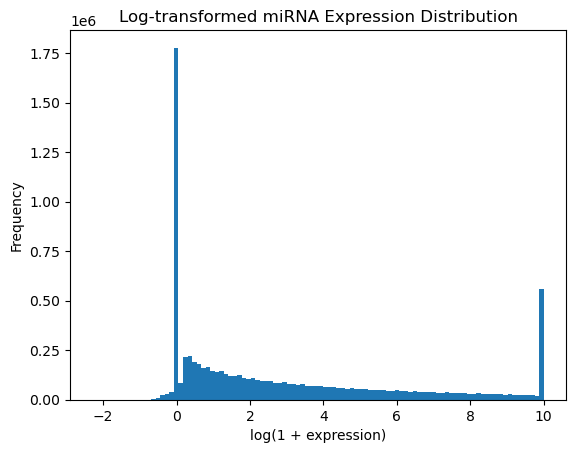

In [71]:
print(mirna_vals.min(), mirna_vals.max())

vals = mirna_vals.values.flatten()

# Remove NaN and Inf safely
vals = vals[np.isfinite(vals)]

# Optional: clip extreme values (helps visualization)
vals = np.clip(vals, -10, 10)

print("Min:", vals.min(), "Max:", vals.max(), "Count:", len(vals))

import matplotlib.pyplot as plt

plt.figure()
plt.hist(vals, bins=100)
plt.title("Log-transformed miRNA Expression Distribution")
plt.xlabel("log(1 + expression)")
plt.ylabel("Frequency")
plt.show()

## miRNA-to-Gene Mapping Strength

Gene-level signal is computed as:

$$
z_{g,s} = \sum_{m} w_{m,g} \cdot x'_{m,s}
$$

This plot shows the distribution of aggregated gene signals after mapping.

Higher values indicate stronger cumulative regulatory pressure from miRNAs.

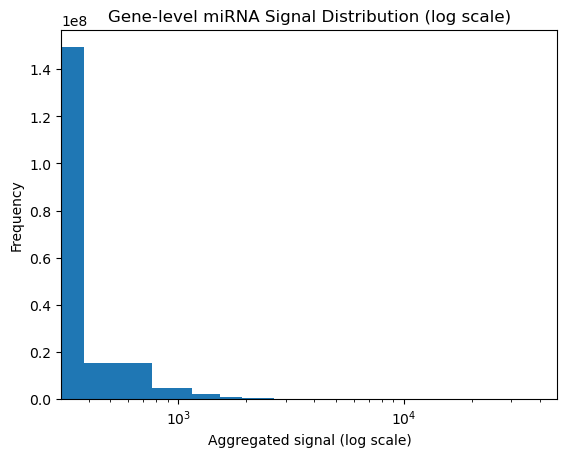

In [72]:
gene_vals = mirna_gene_matrix.iloc[:, 1:].values.flatten()
gene_vals = gene_vals[~np.isnan(gene_vals)]

# remove non-positive values for log scale
gene_vals = gene_vals[gene_vals > 0]

plt.figure()
plt.hist(gene_vals, bins=100)

plt.xscale("log")  # 🔥 log scale on x-axis

plt.title("Gene-level miRNA Signal Distribution (log scale)")
plt.xlabel("Aggregated signal (log scale)")
plt.ylabel("Frequency")

plt.show()

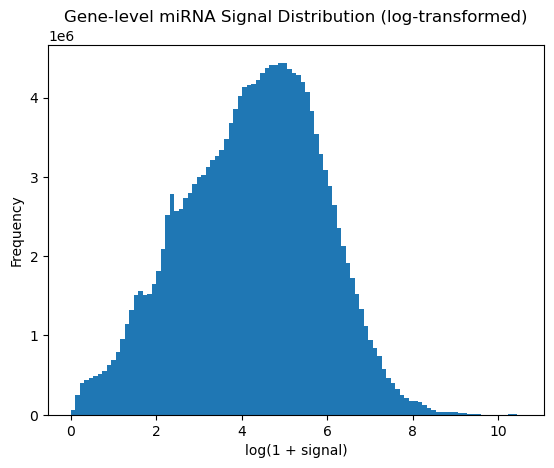

In [73]:
plt.figure()
plt.hist(np.log1p(gene_vals), bins=100)

plt.title("Gene-level miRNA Signal Distribution (log-transformed)")
plt.xlabel("log(1 + signal)")
plt.ylabel("Frequency")

plt.show()

## Gene × Cancer miRNA Matrix

Cancer-level aggregation is computed as:

$$
X_{g,c} = \frac{1}{|\mathcal{S}_c|} \sum_{s \in \mathcal{S}_c} z_{g,s}
$$

This heatmap visualizes gene-level miRNA regulatory signals across cancers.

Patterns reveal:
- Cancer-specific regulatory programs
- Shared oncogenic pathways

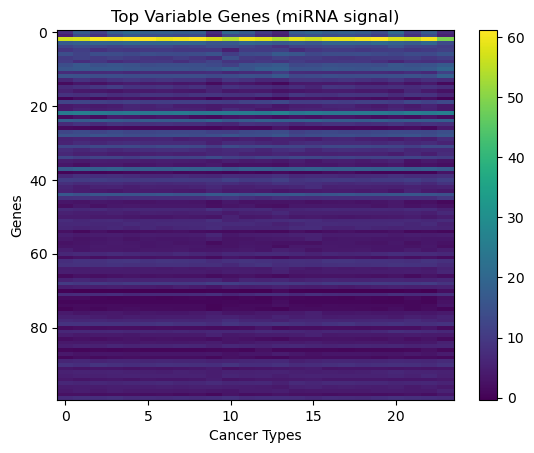

In [74]:
import matplotlib.pyplot as plt

mat = mirna_df.set_index("gene")

# select top variable genes
var = mat.var(axis=1)
top_genes = var.sort_values(ascending=False).head(100).index

plt.figure()
plt.imshow(mat.loc[top_genes], aspect='auto')
plt.title("Top Variable Genes (miRNA signal)")
plt.xlabel("Cancer Types")
plt.ylabel("Genes")
plt.colorbar()
plt.show()

## Gene Importance Ranking

We compute global gene importance:

$$
I_g = \frac{1}{|\mathcal{C}|} \sum_{c} X_{g,c}
$$

This represents the average regulatory strength across cancers.

Highly ranked genes may correspond to:
- Pan-cancer regulators
- Core biological pathways

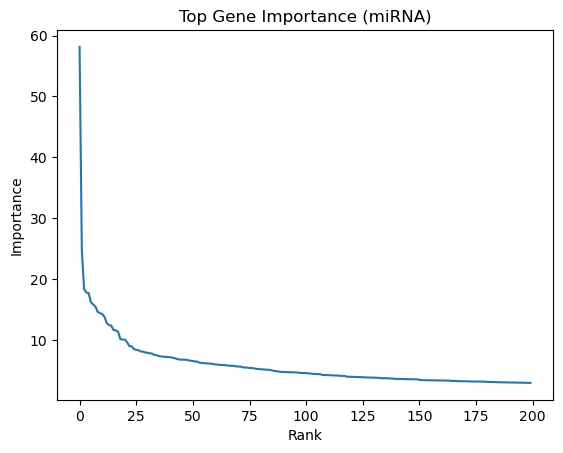

In [75]:
importance = mat.mean(axis=1).sort_values(ascending=False)

plt.figure()
plt.plot(importance.values[:200])
plt.title("Top Gene Importance (miRNA)")
plt.xlabel("Rank")
plt.ylabel("Importance")
plt.show()

## Gene Coverage Across Cancers

We measure how widely a gene is regulated:

$$
C_g = \sum_{c} \mathbf{1}(X_{g,c} > 0)
$$

This indicates how many cancers show miRNA regulation for gene $g$.

- High coverage → pan-cancer relevance  
- Low coverage → cancer-specific regulation

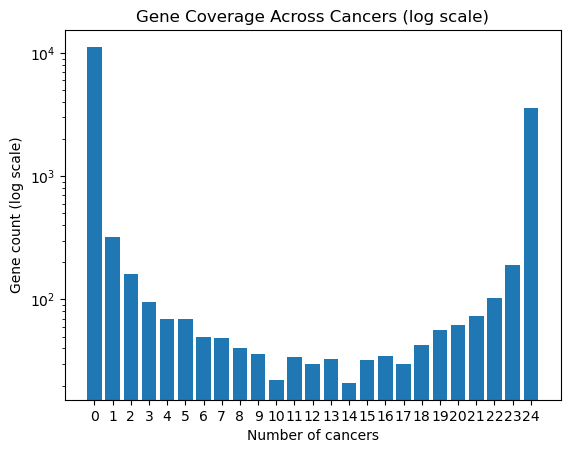

In [76]:
coverage = (mat > 0).sum(axis=1)
counts = coverage.value_counts().sort_index()

plt.figure()
plt.bar(counts.index, counts.values)

plt.yscale("log")  # ✅ log height

plt.title("Gene Coverage Across Cancers (log scale)")
plt.xlabel("Number of cancers")
plt.ylabel("Gene count (log scale)")
plt.xticks(range(int(counts.index.min()), int(counts.index.max()) + 1))
plt.show()

## Cancer Similarity (miRNA Regulation)

We compute correlation between cancer profiles:

$$
\rho(c_i, c_j) = \text{corr}(X_{\cdot,c_i}, X_{\cdot,c_j})
$$

This reveals shared regulatory programs across cancers.

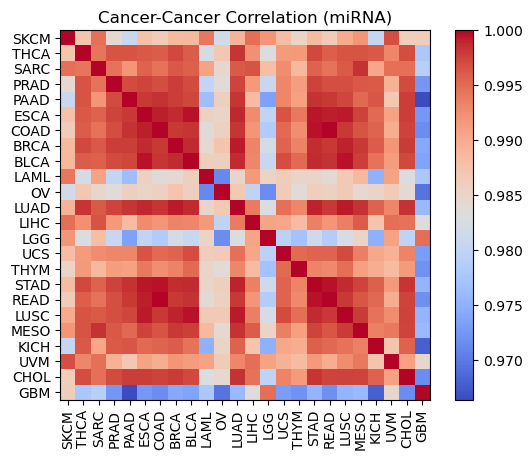

In [84]:
plt.figure()
plt.imshow(corr, cmap="coolwarm")  # 🔥 change colormap
plt.title("Cancer-Cancer Correlation (miRNA)")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

## Select Top Genes for Enrichment

We rank genes based on their aggregated signal across cancers:

\[
\text{Score}(g) = \frac{1}{N} \sum_{c=1}^{N} x_{g,c}
\]

Where:
- \( x_{g,c} \): gene signal in cancer \( c \)

We then select the **top-k genes** for enrichment.

In [78]:
gene_scores = mirna_gene_matrix.set_index("gene").mean(axis=1)
top_genes = gene_scores.sort_values(ascending=False).head(300).index.tolist()

print("Number of selected genes:", len(top_genes))

Number of selected genes: 300


## Run Pathway Enrichment

We query **g:Profiler** to identify enriched pathways.

Sources include:
- GO: Biological Process
- KEGG pathways
- Reactome pathways

---

### Statistical Model

Enrichment is based on over-representation analysis:

\[
p = P(X \ge k)
\]

Where:
- \( k \): overlap between input genes and pathway genes
- Computed using hypergeometric distribution

In [79]:
gp = GProfiler(return_dataframe=True)

enrich = gp.profile(
    organism="hsapiens",
    query=top_genes,
    sources=["GO:BP", "KEGG", "REAC"]
)

enrich.head()

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:BP,GO:0048522,positive regulation of cellular process,4.160031e-55,True,"""Any process that activates or increases the f...",5739,291,211,20972,0.725086,0.036766,query_1,"[GO:0009987, GO:0048518, GO:0050794]"
1,GO:BP,GO:0048518,positive regulation of biological process,6.351433e-53,True,"""Any process that activates or increases the f...",6150,291,215,20972,0.738832,0.034959,query_1,"[GO:0008150, GO:0050789]"
2,GO:BP,GO:0048523,negative regulation of cellular process,9.638036e-51,True,"""Any process that stops, prevents, or reduces ...",5510,291,202,20972,0.694158,0.036661,query_1,"[GO:0009987, GO:0048519, GO:0050794]"
3,GO:BP,GO:0042127,regulation of cell population proliferation,1.572764e-50,True,"""Any process that modulates the frequency, rat...",1639,291,117,20972,0.402062,0.071385,query_1,"[GO:0008283, GO:0050794]"
4,GO:BP,GO:0048519,negative regulation of biological process,6.664681e-50,True,"""Any process that stops, prevents, or reduces ...",5753,291,205,20972,0.704467,0.035634,query_1,"[GO:0008150, GO:0050789]"


## Clean and Rank Enrichment Results

We:
- Sort by statistical significance
- Convert p-values to:

\[
-\log_{10}(p)
\]

This improves visualization and interpretability.

In [80]:
enrich = enrich.sort_values("p_value")
enrich["-log10(p)"] = -np.log10(enrich["p_value"])

# Select top pathways
enrich_top = enrich.head(30)

## Enriched Pathways

Each point represents a pathway:

- X-axis: significance \(-\log_{10}(p)\)
- Y-axis: pathway name
- Size: number of overlapping genes
- Color: pathway database


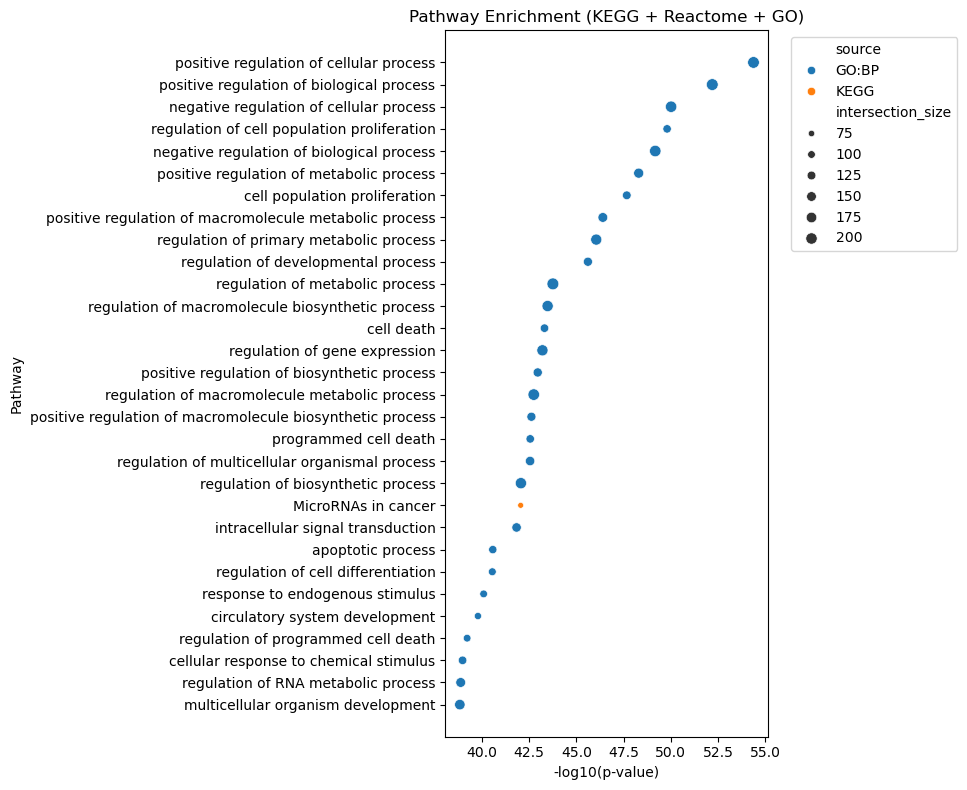

In [81]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=enrich_top,
    x="-log10(p)",
    y="name",
    size="intersection_size",
    hue="source",
)

plt.title("Pathway Enrichment (KEGG + Reactome + GO)")
plt.xlabel("-log10(p-value)")
plt.ylabel("Pathway")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [82]:
# -------------------------------
# Aggregate to cancer level
# -------------------------------
mirna_df = aggregate(mirna_gene_matrix, pheno)

# ensure gene format
mirna_df["gene"] = mirna_df["gene"].str.upper()

print("Final matrix shape:", mirna_df.shape)
mirna_df.head()


[VALIDATE] Cancer aggregated matrix
Shape: (16422, 24)
NaN count: 0
Inf count: 0
Min: -9.88977011494253
Max: 35357.63785714288
Final matrix shape: (16422, 25)


,gene,SKCM,THCA,SARC,PRAD,PAAD,ESCA,COAD,BRCA,BLCA,...,UCS,THYM,STAD,READ,LUSC,MESO,KICH,UVM,CHOL,GBM
0,A1BG,53.806416,67.501863,43.211615,54.708199,68.843297,65.452000,63.101346,62.239433,64.527832,...,74.169286,77.815079,64.814515,63.577692,68.191115,50.625287,66.243596,45.349500,59.138222,36.536
1,A1CF,309.868739,226.573656,226.872654,210.967279,217.255055,227.950974,214.520951,247.456910,247.231352,...,310.649464,348.077937,225.458122,218.990385,271.725890,236.129195,198.521236,285.970250,225.394889,290.474
2,A2M,80.400487,103.417557,74.888846,65.135662,80.854835,80.333026,73.141717,75.145039,74.460373,...,91.915000,93.374206,75.803671,73.277308,82.518943,85.808621,59.929663,67.233625,90.853333,85.922
3,A2ML1,381.107832,308.247803,358.530038,312.218529,377.580604,344.172872,340.490696,373.384421,351.139324,...,437.212679,322.505556,356.652637,338.931731,411.436654,336.713678,221.431124,302.120375,343.110667,208.622
4,A4GALT,68.235088,51.430738,48.660423,37.641195,49.703791,49.886462,50.097309,54.756592,56.771096,...,61.213214,61.697222,51.421540,51.475641,55.880039,53.464598,45.076966,63.503625,51.911111,66.500
